In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

CUDA available: True
GPU: Tesla T4
VRAM: 15.64 GB


In [2]:
!pip install -q -U transformers accelerate bitsandbytes   
#transformers → load and use Qwen2.5-VL
# accelerate → manage GPU/model execution
# bitsandbytes → 4-bit loading so the model fits comfortably
# qwen-vl-utils → Qwen's vision utilities
# pillow → image handling
# opencv-python-headless → image processing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 109.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 49.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 36.3 MB/s eta 0:00:00


In [3]:
!pip install -q qwen-vl-utils pillow opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 58.9 MB/s eta 0:00:00:00:0100:01


In [4]:
import transformers
import accelerate
import bitsandbytes
from PIL import Image

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("All imports successful!")

Transformers: 5.15.0
Accelerate: 1.14.0
All imports successful!


In [5]:
!pip install -q datasets huggingface_hub

In [6]:
!wget https://s3.us-west-2.amazonaws.com/ai2-rowanz/vcr1annots.zip
!unzip vcr1annots.zip

--2026-08-14 18:33:56--  https://s3.us-west-2.amazonaws.com/ai2-rowanz/vcr1annots.zip
Resolving s3.us-west-2.amazonaws.com (s3.us-west-2.amazonaws.com)... 3.5.81.14, 3.5.84.36, 16.12.99.176, ...
Connecting to s3.us-west-2.amazonaws.com (s3.us-west-2.amazonaws.com)|3.5.81.14|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-08-14 18:33:57 ERROR 403: Forbidden.

unzip:  cannot find or open vcr1annots.zip, vcr1annots.zip.zip or vcr1annots.zip.ZIP.


In [7]:
from huggingface_hub import list_repo_files

files = list_repo_files("MMInstruction/M3IT", repo_type="dataset")
vcr_files = [f for f in files if 'vcr' in f.lower()]
print(vcr_files)

['data/reasoning/vcr/instructions.json', 'data/reasoning/vcr/test.jsonl', 'data/reasoning/vcr/train.jsonl', 'data/reasoning/vcr/val.jsonl']


In [8]:
from huggingface_hub import hf_hub_download
import json

val_path = hf_hub_download(
    repo_id="MMInstruction/M3IT",
    filename="data/reasoning/vcr/val.jsonl",
    repo_type="dataset"
)

rows = []
with open(val_path) as f:
    for line in f:
        rows.append(json.loads(line))

print(len(rows), "rows loaded")
print(rows[0].keys())

data/reasoning/vcr/val.jsonl:   0%|          | 0.00/1.04G [00:00<?, ?B/s]

5000 rows loaded
dict_keys(['image_base64_str', 'inputs', 'outputs', 'instructions', 'meta'])


In [9]:
import json

sample = rows[0]
print("INPUTS:\n", sample['inputs'])
print("\nOUTPUTS:\n", sample['outputs'])
print("\nINSTRUCTIONS:\n", sample['instructions'])
print("\nMETA:\n", sample['meta'])
print("\nIMAGE STR (first 100 chars):\n", sample['image_base64_str'][:100])

INPUTS:
 Objects:
The 0-th object is person in the red color box.
The 1-th object is person in the blue color box.
The 2-th object is person in the green color box.
The 3-th object is car in the pink color box.
The 4-th object is cellphone in the light_blue color box.
The 5-th object is clock in the light_green color box.
Question:
How is the 0-th object feeling ?
Answer Choices:
Answer (A) the 0-th object is feeling amused .
Answer (B) the 0-th object is upset and disgusted .
Answer (C) the 0-th object is feeling very scared .
Answer (D) the 0-th object is feeling uncomfortable with the 2-th object .
Rationale Choices:
Rationale (A) the 0-th object ' s mouth has wide eyes and an open mouth .
Rationale (B) When people have their mouth back like that and their eyebrows lowered they are usually disgusted by what they see .
Rationale (C) the 2-th object and the 1-th object and the 0-th object are seated at a dining table where food would be served to them . people unaccustomed to odd or f

In [ ]:
import re
from io import BytesIO
from PIL import Image
import base64

def decode_image(b64_str):
    return Image.open(BytesIO(base64.b64decode(b64_str))).convert('RGB')

def parse_m3it_row(row):
    text = row['inputs']

    q_match = re.search(r'Question:\s*\n(.+?)\nAnswer Choices:', text, re.DOTALL)
    question = q_match.group(1).strip() if q_match else None

    answer_choices = re.findall(r'Answer \([A-D]\)\s*(.+?)\s*\n', text)
    answer_choices = [a.strip() for a in answer_choices]

    rationale_choices = re.findall(r'Rationale \([A-D]\)\s*(.+?)\s*\n', text)
    rationale_choices = [r.strip() for r in rationale_choices]

    outputs = row['outputs'].strip()
    if ' Because ' in outputs:
        ans_text, rat_text = outputs.split(' Because ', 1)
    else:
        ans_text, rat_text = outputs, None
    ans_text = ans_text.strip()
    rat_text = rat_text.strip() if rat_text else None

    answer_label = next((i for i, c in enumerate(answer_choices) if c.strip(' .') == ans_text.strip(' .')), None)
    rationale_label = next((i for i, c in enumerate(rationale_choices) if c.strip(' .') == rat_text.strip(' .')), None) if rat_text else None

    return {
        'question': question,
        'answer_choices': answer_choices,
        'rationale_choices': rationale_choices,
        'answer_label': answer_label,
        'rationale_label': rationale_label,
        'image_base64_str': row['image_base64_str'],   
        'img_path': row['meta'].get('img_path'),
    }
   

0/5000 failed label recovery
How is the 0-th object feeling ?
['the 0-th object is feeling amused .', 'the 0-th object is upset and disgusted .', 'the 0-th object is feeling very scared .', 'the 0-th object is feeling uncomfortable with the 2-th object .']
1
["the 0-th object ' s mouth has wide eyes and an open mouth .", 'When people have their mouth back like that and their eyebrows lowered they are usually disgusted by what they see .', 'the 2-th object and the 1-th object and the 0-th object are seated at a dining table where food would be served to them . people unaccustomed to odd or foreign dishes may make disgusted looks at the thought of eating it .', "the 0-th object ' s expression is twisted in disgust ."]
3


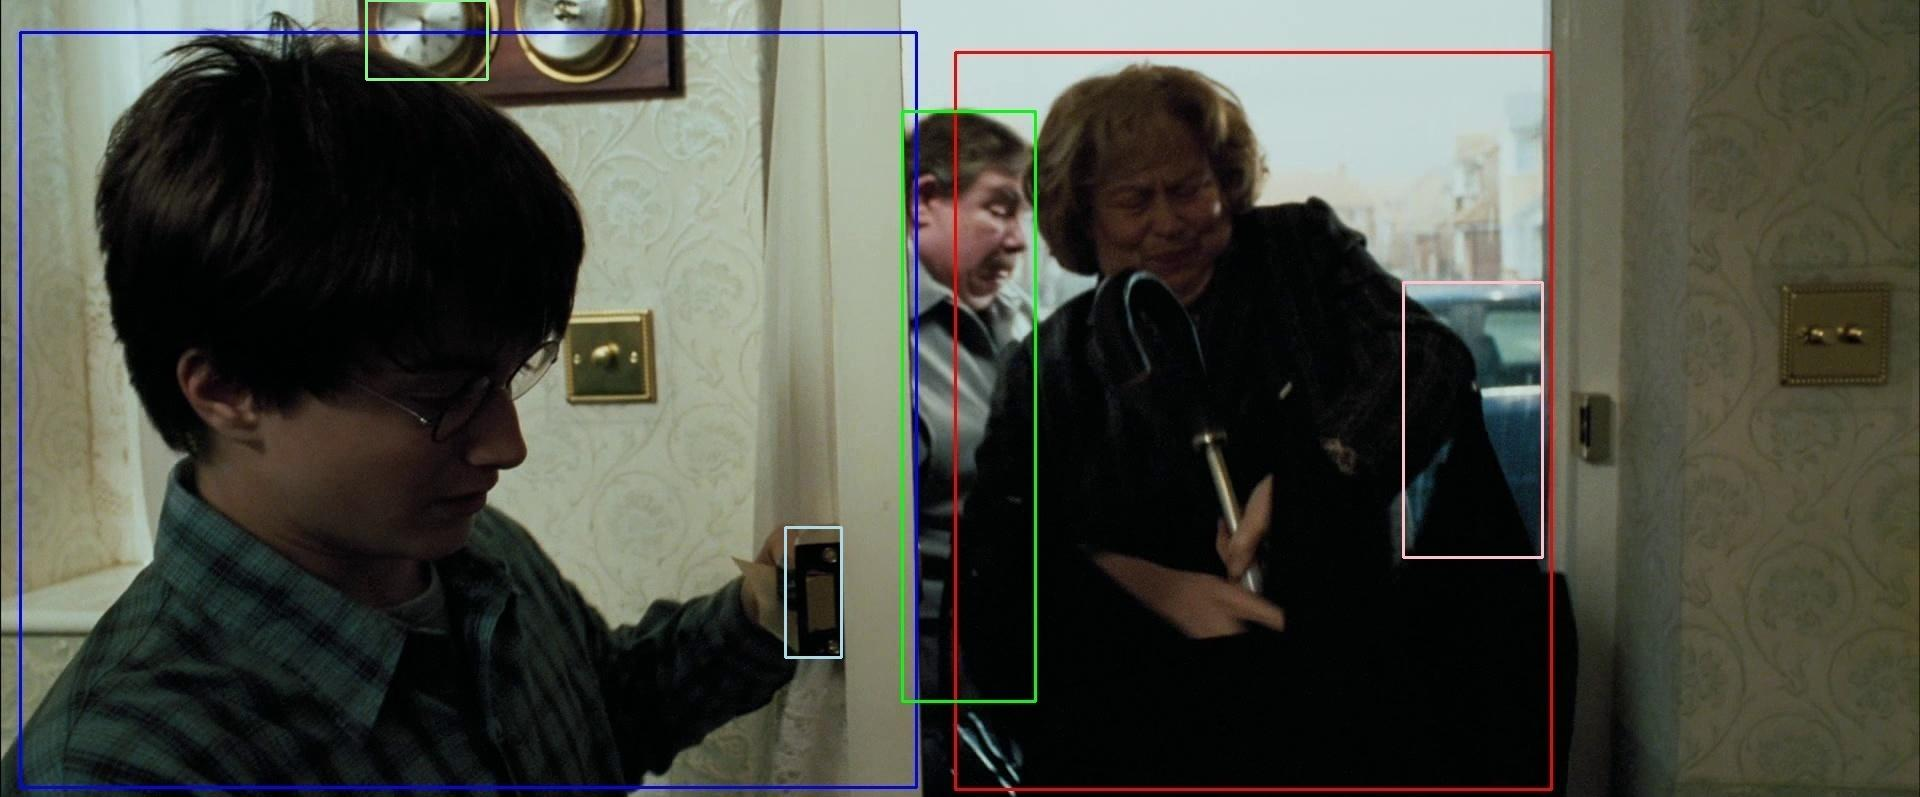

In [ ]:
parsed = [parse_m3it_row(r) for r in rows]
missing = sum(1 for p in parsed if p['answer_label'] is None or p['rationale_label'] is None)
print(f"{missing}/{len(parsed)} failed label recovery")

# spot check
print(parsed[0]['question'])
print(parsed[0]['answer_choices'])
print(parsed[0]['answer_label'])
print(parsed[0]['rationale_choices'])
print(parsed[0]['rationale_label'])
decode_image(parsed[0]['image_base64_str'])  

In [12]:
import random, json

random.seed(0)
random.shuffle(parsed)

HELD_OUT_SIZE = 175  # within the 150-200 range
held_out = parsed[:HELD_OUT_SIZE]
train_pool = parsed[HELD_OUT_SIZE:]

print(f"held_out: {len(held_out)}, train_pool: {len(train_pool)}")

with open('held_out.json', 'w') as f:
    json.dump([{**r, 'image': None} for r in held_out], f)  # drop image for the json dump, keep held_out (with images) in memory for actual eval

held_out: 175, train_pool: 4825


In [13]:
!pip install -q -U bitsandbytes>=0.46.1

import bitsandbytes as bnb
print(bnb.__version__)

0.50.1


In [13]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map='auto',
    low_cpu_mem_usage=True,
    attn_implementation='sdpa',
)

processor = AutoProcessor.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    min_pixels=256*28*28,
    max_pixels=768*28*28,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

chat_template.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
print(model.device)
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")

cuda:0
1.089664512 GB allocated


In [17]:
def score_candidates(image, question, candidates):
    scores = []
    for cand in candidates:
        prompt = (
            f'Question: {question}\n'
            f'Proposed answer: {cand}\n'
            'Is this proposed answer correct? Answer strictly Yes or No.'
        )
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
        with torch.no_grad():
            out = model(**inputs)
        logits = out.logits[0, -1]
        yes_id = processor.tokenizer.encode('Yes', add_special_tokens=False)[0]
        no_id = processor.tokenizer.encode('No', add_special_tokens=False)[0]
        yn_logits = torch.tensor([logits[yes_id], logits[no_id]])
        scores.append(torch.softmax(yn_logits, dim=0)[0].item())
    return scores.index(max(scores)), scores


def score_rationale(image, question, predicted_answer, rationale_candidates):
    scores = []
    for rat in rationale_candidates:
        prompt = (
            f'Question: {question}\n'
            f'Answer: {predicted_answer}\n'
            f'Proposed rationale: {rat}\n'
            'Does this rationale correctly explain the answer? Answer strictly Yes or No.'
        )
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
        with torch.no_grad():
            out = model(**inputs)
        logits = out.logits[0, -1]
        yes_id = processor.tokenizer.encode('Yes', add_special_tokens=False)[0]
        no_id = processor.tokenizer.encode('No', add_special_tokens=False)[0]
        yn_logits = torch.tensor([logits[yes_id], logits[no_id]])
        scores.append(torch.softmax(yn_logits, dim=0)[0].item())
    return scores.index(max(scores)), scores


# sanity check on one row
test_row = train_pool[0]
img = decode_image(test_row['image_base64_str'])
a_idx, a_scores = score_candidates(img, test_row['question'], test_row['answer_choices'])
print("predicted answer idx:", a_idx, "scores:", a_scores)

pred_answer_text = test_row['answer_choices'][a_idx]
r_idx, r_scores = score_rationale(img, test_row['question'], pred_answer_text, test_row['rationale_choices'])
print("predicted rationale idx:", r_idx, "scores:", r_scores)

predicted answer idx: 0 scores: [0.437744140625, 0.140380859375, 0.12939453125, 0.33447265625]
predicted rationale idx: 3 scores: [0.1461181640625, 0.1710205078125, 0.37744140625, 0.46484375]


In [ ]:
from tqdm import tqdm
import time

start = time.time()
test_batch = train_pool[:20]
correct_a = 0
for row in tqdm(test_batch):
    img = decode_image(row['image_base64_str'])
    a_idx, a_scores = score_candidates(img, row['question'], row['answer_choices'])
    if a_idx == row['answer_label']:
        correct_a += 1
    del img

elapsed = time.time() - start
print(f"{elapsed:.1f}s for 20 rows -> ~{elapsed/20:.2f}s/row")
print(f"Estimated full baseline time ({len(train_pool)} rows): {elapsed/20*len(train_pool)/60:.1f} min")
print(f"Sample Q->A acc on these 20: {correct_a/20:.2f}")

100%|██████████| 20/20 [01:17<00:00,  3.86s/it]

77.2s for 20 rows -> ~3.86s/row
Estimated full baseline time (4825 rows): 310.3 min
Sample Q->A acc on these 20: 0.60


In [22]:
import random

random.seed(1)  # different seed from the held_out split, so we're not just re-picking the same rows
BASELINE_SAMPLE_SIZE = 800  # ~50 min at current pace, adjust if you want faster/slower

baseline_sample = random.sample(train_pool, BASELINE_SAMPLE_SIZE)
print(f"Running baseline on {len(baseline_sample)} rows (~{len(baseline_sample)*3.86/60:.0f} min estimated)")
chunk_1 = baseline_sample[:400]
chunk_2 = baseline_sample[400:800]

Running baseline on 800 rows (~51 min estimated)


In [23]:
import torch, gc

try:
    del img
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

1.368921088 GB allocated
1.388314624 GB reserved


In [24]:
results = []
correct_a = 0

In [ ]:
import json
from tqdm import tqdm

results = []
correct_a = 0
correct_ar = 0

for i, row in enumerate(tqdm(chunk_1)):
    img = decode_image(row['image_base64_str'])
    a_idx, a_scores = score_candidates(img, row['question'], row['answer_choices'])
    pred_answer_text = row['answer_choices'][a_idx]
    r_idx, r_scores = score_rationale(img, row['question'], pred_answer_text, row['rationale_choices'])
    results.append({
        'pred_answer': a_idx, 'answer_scores': a_scores,
        'pred_rationale': r_idx, 'rationale_scores': r_scores,
        'answer_label': row['answer_label'], 'rationale_label': row['rationale_label'],
    })
    if a_idx == row['answer_label']:
        correct_a += 1
        if r_idx == row['rationale_label']:
            correct_ar += 1
    del img

    if (i + 1) % 50 == 0:
        json.dump(results, open('/kaggle/working/baseline_predictions_chunk1_partial.json', 'w'))

print('Q->A (chunk 1):', correct_a / len(chunk_1))
print('Q->AR (chunk 1):', correct_ar / len(chunk_1))
print('QA->R (chunk 1):', correct_ar / correct_a)
json.dump(results, open('/kaggle/working/baseline_predictions_chunk1.json', 'w'))

100%|██████████| 400/400 [51:24<00:00,  7.71s/it]

Q->A accuracy (chunk 1, 400 rows): 0.6225


In [ ]:
correct_a_2 = 0
correct_ar_2 = 0

for row in tqdm(chunk_2):
    img = decode_image(row['image_base64_str'])
    a_idx, a_scores = score_candidates(img, row['question'], row['answer_choices'])
    pred_answer_text = row['answer_choices'][a_idx]
    r_idx, r_scores = score_rationale(img, row['question'], pred_answer_text, row['rationale_choices'])
    results.append({
        'pred_answer': a_idx, 'answer_scores': a_scores,
        'pred_rationale': r_idx, 'rationale_scores': r_scores,
        'answer_label': row['answer_label'], 'rationale_label': row['rationale_label'],
    })
    if a_idx == row['answer_label']:
        correct_a_2 += 1
        if r_idx == row['rationale_label']:
            correct_ar_2 += 1
    del img

print('Q->A (chunk 2):', correct_a_2 / len(chunk_2))
print('Q->AR (chunk 2):', correct_ar_2 / len(chunk_2))
print('QA->R (chunk 2):', correct_ar_2 / correct_a_2)

100%|██████████| 400/400 [51:17<00:00,  7.69s/it]

Q->A accuracy (chunk 2, 400 rows): 0.615


In [ ]:
import json

print(len(results))  

total_correct = sum(1 for r in results if r['pred_answer'] == r['answer_label'])
print('Q->A accuracy (combined, 800 rows):', total_correct / len(results))

json.dump(results, open('/kaggle/working/baseline_predictions.json', 'w'))

800
Q->A accuracy (combined, 800 rows): 0.61875


In [ ]:
try:
    print('results in memory:', len(results))
except NameError:
    print('results is gone from memory')

!find /kaggle/working -type f

results is gone from memory
/kaggle/working/lora_final_adapter/adapter_model.safetensors
/kaggle/working/lora_final_adapter/adapter_config.json
/kaggle/working/lora_final_adapter/README.md
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/lora_real_checkpoints/checkpoint-370/training_args.bin
/kaggle/working/lora_real_checkpoints/checkpoint-370/trainer_state.json
/kaggle/working/lora_real_checkpoints/checkpoint-370/optimizer.pt
/kaggle/working/lora_real_checkpoints/checkpoint-370/adapter_model.safetensors
/kaggle/working/lora_real_checkpoints/checkpoint-370/adapter_config.json
/kaggle/working/lora_real_checkpoints/checkpoint-370/scheduler.pt
/kaggle/working/lora_real_checkpoints/checkpoint-370/README.md
/kaggle/working/lora_real_checkpoints/checkpoint-370/rng_state.pth
/kaggle/working/lora_real_checkpoints/checkpoint-200/training_args.bin
/kaggle/working/lora_real_checkpoints/checkpoint-200/trainer_state.json
/kaggle/working/lora_real_checkpoints/checkpoint-2

In [50]:
import json
results = json.load(open('/kaggle/working/finetuned_predictions.json'))
print(len(results))
print(results[0])

175
{'pred_answer': 3, 'answer_scores': [0.2018132209777832, 0.29421496391296387, 0.22270014882087708, 0.5926666259765625], 'pred_rationale': 3, 'rationale_scores': [0.053403329104185104, 0.012431650422513485, 0.04742587357759476, 0.11920291185379028], 'answer_label': 1, 'rationale_label': 3}


In [30]:
def build_training_examples(row):
    examples = []
    for i, cand in enumerate(row['answer_choices']):
        label = 'Yes' if i == row['answer_label'] else 'No'
        prompt = (f"Question: {row['question']}\n"
                  f"Proposed answer: {cand}\n"
                  "Is this proposed answer correct? Answer strictly Yes or No.")
        examples.append({
            'image_base64_str': row['image_base64_str'],
            'prompt': prompt,
            'label': label
        })

    gold_answer_text = row['answer_choices'][row['answer_label']]
    for i, rat in enumerate(row['rationale_choices']):
        label = 'Yes' if i == row['rationale_label'] else 'No'
        prompt = (f"Question: {row['question']}\n"
                  f"Answer: {gold_answer_text}\n"
                  f"Proposed rationale: {rat}\n"
                  "Does this rationale correctly explain the answer? Answer strictly Yes or No.")
        examples.append({
            'image_base64_str': row['image_base64_str'],
            'prompt': prompt,
            'label': label
        })
    return examples


training_examples = []
for row in tqdm(train_pool):
    training_examples.extend(build_training_examples(row))

print(f"{len(training_examples)} training examples built from {len(train_pool)} questions")

100%|██████████| 4825/4825 [00:00<00:00, 90846.12it/s]

38600 training examples built from 4825 questions


In [31]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import TrainingArguments

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir='/kaggle/working/lora_checkpoints',
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_steps=200,
    save_total_limit=3,
    eval_strategy='steps',
    eval_steps=200,
)

trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960


In [ ]:
import torch
from torch.utils.data import Dataset

class VCRTrainingDataset(Dataset):
    def __init__(self, examples, processor):
        self.examples = examples
        self.processor = processor

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        img = decode_image(ex['image_base64_str'])

        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': ex['prompt']}
        ]}]
        prompt_text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        full_text = prompt_text + ex['label']

        inputs = self.processor(text=[full_text], images=[img], return_tensors='pt')

        prompt_only = self.processor(text=[prompt_text], images=[img], return_tensors='pt')
        prompt_len = prompt_only['input_ids'].shape[1]

        input_ids = inputs['input_ids'][0]
        labels = input_ids.clone()
        labels[:prompt_len] = -100

        return {
            'input_ids': input_ids,
            'attention_mask': inputs['attention_mask'][0],
            'labels': labels,
            'pixel_values': inputs['pixel_values'],       
            'image_grid_thw': inputs['image_grid_thw'],   
        }

def collate_fn(batch):
    item = batch[0]
    out = {}
    for k, v in item.items():
        if k in ('pixel_values', 'image_grid_thw'):
            out[k] = v  
        else:
            out[k] = v.unsqueeze(0)  
    return out

In [44]:
import random
random.seed(2)
smoke_examples = random.sample(training_examples, 200)
smoke_dataset = VCRTrainingDataset(smoke_examples, processor)

from transformers import Trainer

smoke_args = TrainingArguments(
    output_dir='/kaggle/working/lora_smoke_test',
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=5,
    save_strategy='no',
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=smoke_args,
    train_dataset=smoke_dataset,
    data_collator=collate_fn,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,0.000000
10,0.000000
15,0.000000
20,0.000000
25,0.000000


TrainOutput(global_step=25, training_loss=0.0, metrics={'train_runtime': 654.6807, 'train_samples_per_second': 0.305, 'train_steps_per_second': 0.038, 'total_flos': 3367272429846528.0, 'train_loss': 0.0, 'epoch': 1.0})

In [ ]:
sample = smoke_dataset[0]

print("input_ids shape:", sample['input_ids'].shape)
print("labels shape:", sample['labels'].shape)

valid_label_count = (sample['labels'] != -100).sum().item()
print("valid (non -100) label tokens:", valid_label_count)

valid_tokens = sample['labels'][sample['labels'] != -100]
if len(valid_tokens) > 0:
    print("decoded target tokens:", processor.tokenizer.decode(valid_tokens))
else:
    print("NO valid target tokens — everything is masked. This is the bug.")

print("last 10 input_ids:", sample['input_ids'][-10:])
print("decoded tail:", processor.tokenizer.decode(sample['input_ids'][-10:]))

input_ids shape: torch.Size([786])
labels shape: torch.Size([786])
valid (non -100) label tokens: 1
decoded target tokens: No
last 10 input_ids: tensor([  7414,    476,   2308,     13, 151645,    198, 151644,  77091,    198,
          2753])
decoded tail:  Yes or No.<|im_end|>
<|im_start|>assistant
No


In [ ]:
model.eval()  
sample = smoke_dataset[0]

batch = {
    'input_ids': sample['input_ids'].unsqueeze(0).to(model.device),
    'attention_mask': sample['attention_mask'].unsqueeze(0).to(model.device),
    'labels': sample['labels'].unsqueeze(0).to(model.device),
    'pixel_values': sample['pixel_values'].to(model.device),
    'image_grid_thw': sample['image_grid_thw'].to(model.device),
}

with torch.no_grad():
    out = model(**batch)

print("loss:", out.loss)
print("logits shape:", out.logits.shape)
print("any NaN in logits:", torch.isnan(out.logits).any().item())
print("any Inf in logits:", torch.isinf(out.logits).any().item())

model.train()  # switch back

loss: tensor(nan, device='cuda:0')
logits shape: torch.Size([1, 786, 151936])
any NaN in logits: True
any Inf in logits: False


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
                (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
                (up_proj): Linear4bit(

In [ ]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, 
    bnb_4bit_quant_type='nf4',
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,              
    device_map='auto',
    low_cpu_mem_usage=True,
    attn_implementation='sdpa',
)

processor = AutoProcessor.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    min_pixels=256*28*28,
    max_pixels=768*28*28,
)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [48]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960


In [ ]:
smoke_args = TrainingArguments(
    output_dir='/kaggle/working/lora_smoke_test',
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    bf16=True,          
    logging_steps=5,
    save_strategy='no',
    report_to='none',
)

In [ ]:
smoke_dataset = VCRTrainingDataset(smoke_examples, processor)  

model.eval()
sample = smoke_dataset[0]

batch = {
    'input_ids': sample['input_ids'].unsqueeze(0).to(model.device),
    'attention_mask': sample['attention_mask'].unsqueeze(0).to(model.device),
    'labels': sample['labels'].unsqueeze(0).to(model.device),
    'pixel_values': sample['pixel_values'].to(model.device),
    'image_grid_thw': sample['image_grid_thw'].to(model.device),
}

with torch.no_grad():
    out = model(**batch)

print("loss:", out.loss)
print("any NaN in logits:", torch.isnan(out.logits).any().item())

model.train()

loss: tensor(0.0283, device='cuda:0')
any NaN in logits: False


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
                (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
                (up_proj): Linear4bit(

In [ ]:
from transformers import Trainer, TrainingArguments

smoke_dataset = VCRTrainingDataset(smoke_examples, processor)  

smoke_args = TrainingArguments(
    output_dir='/kaggle/working/lora_smoke_test',
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    bf16=True,              
    logging_steps=5,
    save_strategy='no',
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=smoke_args,
    train_dataset=smoke_dataset,
    data_collator=collate_fn,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,0.451301
10,0.880535
15,0.682926
20,0.483431
25,0.411371


TrainOutput(global_step=25, training_loss=0.5819128513336181, metrics={'train_runtime': 3287.7882, 'train_samples_per_second': 0.061, 'train_steps_per_second': 0.008, 'total_flos': 3367272429846528.0, 'train_loss': 0.5819128513336181, 'epoch': 1.0})

In [54]:
import torch
print(f"Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Allocated: 4.39 GB
Reserved: 8.54 GB
Total GPU memory: 15.64 GB


In [55]:
import torch, gc
del model, trainer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
#this cell is not USEFUL IT IS BROKEN
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type='nf4',
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map={'': 0},          
    low_cpu_mem_usage=True,
    attn_implementation='sdpa',
)

processor = AutoProcessor.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    min_pixels=256*28*28,
    max_pixels=512*28*28,        
)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [ ]:
#this cell is not USEFUL IT IS BROKEN
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_disable()   

lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960


In [59]:
smoke_args.gradient_accumulation_steps = 4

trainer = Trainer(
    model=model,
    args=smoke_args,
    train_dataset=smoke_dataset,
    data_collator=collate_fn,
)
trainer.train()

OutOfMemoryError: CUDA out of memory. Tried to allocate 560.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 402.81 MiB is free. Including non-PyTorch memory, this process has 14.17 GiB memory in use. Of the allocated memory 13.56 GiB is allocated by PyTorch, and 480.92 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [60]:
import torch, gc

try:
    del trainer
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Allocated: 13.44 GB
Reserved: 14.24 GB


In [61]:
import os
print(os.listdir('/kaggle/working'))

['=0.46.1', 'baseline_predictions_chunk1_partial.json', 'baseline_predictions_chunk1.json', 'held_out.json', '.virtual_documents', 'baseline_predictions.json', 'lora_smoke_test']


In [28]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type='nf4',
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map={'': 0},
    low_cpu_mem_usage=True,
    attn_implementation='sdpa',
)

processor = AutoProcessor.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct',
    min_pixels=256*28*28,
    max_pixels=512*28*28,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

chat_template.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()   

lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960


In [31]:
def score_candidates(image, question, candidates):
    scores = []
    for cand in candidates:
        prompt = (
            f'Question: {question}\n'
            f'Proposed answer: {cand}\n'
            'Is this proposed answer correct? Answer strictly Yes or No.'
        )
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
        with torch.no_grad():
            out = model(**inputs)
        logits = out.logits[0, -1]
        yes_id = processor.tokenizer.encode('Yes', add_special_tokens=False)[0]
        no_id = processor.tokenizer.encode('No', add_special_tokens=False)[0]
        yn_logits = torch.tensor([logits[yes_id], logits[no_id]])
        scores.append(torch.softmax(yn_logits, dim=0)[0].item())
    return scores.index(max(scores)), scores


def score_rationale(image, question, predicted_answer, rationale_candidates):
    scores = []
    for rat in rationale_candidates:
        prompt = (
            f'Question: {question}\n'
            f'Answer: {predicted_answer}\n'
            f'Proposed rationale: {rat}\n'
            'Does this rationale correctly explain the answer? Answer strictly Yes or No.'
        )
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
        with torch.no_grad():
            out = model(**inputs)
        logits = out.logits[0, -1]
        yes_id = processor.tokenizer.encode('Yes', add_special_tokens=False)[0]
        no_id = processor.tokenizer.encode('No', add_special_tokens=False)[0]
        yn_logits = torch.tensor([logits[yes_id], logits[no_id]])
        scores.append(torch.softmax(yn_logits, dim=0)[0].item())
    return scores.index(max(scores)), scores

In [32]:
import torch
from torch.utils.data import Dataset

class VCRTrainingDataset(Dataset):
    def __init__(self, examples, processor):
        self.examples = examples
        self.processor = processor

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        img = decode_image(ex['image_base64_str'])

        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': ex['prompt']}
        ]}]
        prompt_text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        full_text = prompt_text + ex['label']

        inputs = self.processor(text=[full_text], images=[img], return_tensors='pt')
        prompt_only = self.processor(text=[prompt_text], images=[img], return_tensors='pt')
        prompt_len = prompt_only['input_ids'].shape[1]

        input_ids = inputs['input_ids'][0]
        labels = input_ids.clone()
        labels[:prompt_len] = -100

        return {
            'input_ids': input_ids,
            'attention_mask': inputs['attention_mask'][0],
            'labels': labels,
            'pixel_values': inputs['pixel_values'],
            'image_grid_thw': inputs['image_grid_thw'],
        }


def collate_fn(batch):
    item = batch[0]
    out = {}
    for k, v in item.items():
        if k in ('pixel_values', 'image_grid_thw'):
            out[k] = v
        else:
            out[k] = v.unsqueeze(0)
    return out

In [33]:
def build_training_examples(row):
    examples = []
    for i, cand in enumerate(row['answer_choices']):
        label = 'Yes' if i == row['answer_label'] else 'No'
        prompt = (f"Question: {row['question']}\n"
                  f"Proposed answer: {cand}\n"
                  "Is this proposed answer correct? Answer strictly Yes or No.")
        examples.append({'image_base64_str': row['image_base64_str'], 'prompt': prompt, 'label': label})

    gold_answer_text = row['answer_choices'][row['answer_label']]
    for i, rat in enumerate(row['rationale_choices']):
        label = 'Yes' if i == row['rationale_label'] else 'No'
        prompt = (f"Question: {row['question']}\n"
                  f"Answer: {gold_answer_text}\n"
                  f"Proposed rationale: {rat}\n"
                  "Does this rationale correctly explain the answer? Answer strictly Yes or No.")
        examples.append({'image_base64_str': row['image_base64_str'], 'prompt': prompt, 'label': label})
    return examples

training_examples = []
for row in train_pool:
    training_examples.extend(build_training_examples(row))
print(f"{len(training_examples)} training examples built")

import random
random.seed(2)
smoke_examples = random.sample(training_examples, 200)
smoke_dataset = VCRTrainingDataset(smoke_examples, processor)

38600 training examples built


In [34]:
from transformers import TrainingArguments, Trainer

smoke_args = TrainingArguments(
    output_dir='/kaggle/working/lora_smoke_test',
    per_device_train_batch_size=1,
    gradient_accumulation_steps=6,
    num_train_epochs=1,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=5,
    save_strategy='no',
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=smoke_args,
    train_dataset=smoke_dataset,
    data_collator=collate_fn,
)
trainer.train()

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
5,0.341911
10,1.334276
15,0.559787


TrainOutput(global_step=17, training_loss=0.6938930083723629, metrics={'train_runtime': 897.9414, 'train_samples_per_second': 0.223, 'train_steps_per_second': 0.019, 'total_flos': 1154779133313024.0, 'train_loss': 0.6938930083723629, 'epoch': 1.0})

In [38]:
import inspect
inspect.getsource(collate_fn)

"def collate_fn(batch):\n    item = batch[0]\n    out = {}\n    for k, v in item.items():\n        if k in ('pixel_values', 'image_grid_thw'):\n            out[k] = v\n        else:\n            out[k] = v.unsqueeze(0)\n    return out\n"

In [39]:
import random
random.seed(3)

REAL_TRAIN_SIZE = 4500
real_training_sample = random.sample(training_examples, REAL_TRAIN_SIZE)
real_dataset = VCRTrainingDataset(real_training_sample, processor)
print(f"Training on {len(real_training_sample)} examples (~{len(real_training_sample)*4.5/3600:.1f} hrs estimated)")

Training on 4500 examples (~5.6 hrs estimated)


In [ ]:
from transformers import TrainingArguments, Trainer

real_args = TrainingArguments(
    output_dir='/kaggle/working/lora_real_checkpoints',
    per_device_train_batch_size=1,
    gradient_accumulation_steps=6,
    max_steps=370,              
    learning_rate=2e-4,
    bf16=True,
    logging_steps=10,
    save_steps=50,
    save_total_limit=5,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=real_args,
    train_dataset=real_dataset,
    data_collator=collate_fn,
)

trainer.train()

Step,Training Loss
10,0.440983
20,0.870397
30,0.455334
40,0.432652
50,0.452679
60,0.693613
70,0.562051
80,0.482961
90,0.727966
100,0.495533


TrainOutput(global_step=370, training_loss=0.4742863416671753, metrics={'train_runtime': 19915.6164, 'train_samples_per_second': 0.223, 'train_steps_per_second': 0.019, 'total_flos': 2.556090453570355e+16, 'train_loss': 0.4742863416671753, 'epoch': 0.9866666666666667})

In [43]:
model.save_pretrained('/kaggle/working/lora_final_adapter')
print("Adapter saved")

Adapter saved


In [44]:
model.eval()
print("Model in eval mode, ready to score")

Model in eval mode, ready to score


In [45]:
from tqdm import tqdm
import json

finetuned_results = []
correct_a = 0
correct_ar = 0

for row in tqdm(held_out):
    img = decode_image(row['image_base64_str'])
    a_idx, a_scores = score_candidates(img, row['question'], row['answer_choices'])
    pred_answer_text = row['answer_choices'][a_idx]
    r_idx, r_scores = score_rationale(img, row['question'], pred_answer_text, row['rationale_choices'])

    a_correct = (a_idx == row['answer_label'])
    r_correct = (r_idx == row['rationale_label'])

    finetuned_results.append({
        'pred_answer': a_idx, 'answer_scores': a_scores,
        'pred_rationale': r_idx, 'rationale_scores': r_scores,
        'answer_label': row['answer_label'], 'rationale_label': row['rationale_label'],
    })
    if a_correct:
        correct_a += 1
        if r_correct:
            correct_ar += 1
    del img

qa_acc = correct_a / len(held_out)
qar_acc = correct_ar / len(held_out)
print(f"Q->A accuracy (fine-tuned): {qa_acc:.4f}")
print(f"Q->AR accuracy (fine-tuned): {qar_acc:.4f}")

json.dump(finetuned_results, open('/kaggle/working/finetuned_predictions.json', 'w'))

100%|██████████| 175/175 [1:12:42<00:00, 24.93s/it]

Q->A accuracy (fine-tuned): 0.6971
Q->AR accuracy (fine-tuned): 0.4800


In [ ]:
qa_r_acc = correct_ar / correct_a  
print(f"QA->R accuracy (fine-tuned): {qa_r_acc:.4f}")

QA->R accuracy (fine-tuned): 0.6885


In [51]:
import os

path = "/kaggle/working/lora_final_adapter"

print("Exists:", os.path.exists(path))

if os.path.exists(path):
    print("\nFiles inside adapter:")
    for f in os.listdir(path):
        print("  ", f)
else:
    print("❌ LoRA adapter folder is NOT present")

Exists: True

Files inside adapter:
   adapter_model.safetensors
   adapter_config.json
   README.md


In [52]:
!du -sh /kaggle/working/lora_real_checkpoints
!du -sh /kaggle/working/lora_final_adapter

424M	/kaggle/working/lora_real_checkpoints
29M	/kaggle/working/lora_final_adapter


In [54]:
import huggingface_hub
print(huggingface_hub.__version__)
print(huggingface_hub.__file__)

1.11.0
/usr/local/lib/python3.12/dist-packages/huggingface_hub/__init__.py


In [55]:
import sys
!{sys.executable} -m pip install --force-reinstall --no-cache-dir "huggingface_hub==1.27.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 350.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 308.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 323.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 215.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 290.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 323.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 364.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 390.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 284.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 288.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [56]:
!hf version

Hint: The `hf-cli` skill is not installed. Run `hf skills add -g --claude` to teach your AI agents how to use the `hf` CLI.
✓ hf version
  version: 1.27.0


In [60]:
import getpass
import os

os.environ["HF_TOKEN"] = getpass.getpass("Paste your Hugging Face token: ")

Paste your Hugging Face token:  ········


In [61]:
!hf auth login --token "$HF_TOKEN"

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `VCR` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [63]:
import os

print("Adapter:", os.path.exists("/kaggle/working/lora_final_adapter"))
print("Checkpoints:", os.path.exists("/kaggle/working/lora_real_checkpoints"))

Adapter: True
Checkpoints: True


In [64]:
!hf upload funezocode/lora-vcr-finetuned \
    /kaggle/working/lora_final_adapter \
    lora_final_adapter

Found 3 files to upload
  Preparing   ████████████████████  3 / 3 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  0 / 1 files
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 3
  Preparing   ████████████████████  3 / 3 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  0 / 1 files  560kB · 1.12MB/s
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 3
  Preparing   ████████████████████  3 / 3 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  0 / 1 files  11.2MB · 7.16MB/s
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 3
  Preparing   ████████████████████  3 / 3 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  0 / 1 files  29.5MB · 16.0MB/s
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 3
  Preparing   ████████████████████  3 / 3 ✓
  Uploading   ████████████████████  1 / 1 files  29.5MB · 11.2MB/s ✓
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 3
  Preparing   ████████████████████  3 / 3 ✓
  Uploading   ████████████████████  1 / 1 files  29.5MB · 11.2MB/s ✓
  Committing  ████████████████████  3 / 3 ✓
✓ Uploaded
  url: https://huggingface.co/funezocode/lora-vcr-finetuned/c

In [65]:
!hf upload funezocode/lora-vcr-finetuned \
    /kaggle/working/lora_real_checkpoints \
    lora_real_checkpoints


Found 40 files to upload
  Preparing   ████████████████████  40 / 40 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  0 / 25 files
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 40
  Preparing   ████████████████████  40 / 40 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  0 / 25 files
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 40
  Preparing   ████████████████████  40 / 40 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  0 / 25 files
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 40
  Preparing   ████████████████████  40 / 40 ✓
  Uploading   ░░░░░░░░░░░░░░░░░░░░  1 / 25 files
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 40
  Preparing   ████████████████████  40 / 40 ✓
  Uploading   █░░░░░░░░░░░░░░░░░░░  2 / 25 files  2.80MB · 5.59MB/s
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 40
  Preparing   ████████████████████  40 / 40 ✓
  Uploading   █░░░░░░░░░░░░░░░░░░░  2 / 25 files  38.0MB · 25.0MB/s
  Committing  ░░░░░░░░░░░░░░░░░░░░  0 / 40
  Preparing   ████████████████████  40 / 40 ✓
  Uploading   █░░░░░░░░░░░░░░░░░░░  2 / 25 files  98.2MB · 53.6

In [2]:
import os
print(os.listdir('/kaggle/working'))

['.virtual_documents']


In [16]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

In [17]:
from huggingface_hub import snapshot_download

local_repo_path = snapshot_download(repo_id="funezocode/lora-vcr-finetuned")
print(local_repo_path)

Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]

/root/.cache/huggingface/hub/models--funezocode--lora-vcr-finetuned/snapshots/87df20da9b106038333b2dabee3b173f191faad0


In [ ]:
import os
adapter_path = os.path.join(local_repo_path, "lora_final_adapter")
print(os.listdir(adapter_path))  # sanity check

['adapter_config.json', 'README.md', 'adapter_model.safetensors']


In [19]:
from peft import PeftModel

model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()
print("Fine-tuned model loaded successfully")


Fine-tuned model loaded successfully


In [20]:
def score_candidates(image, question, candidates):
    scores = []
    for cand in candidates:
        prompt = (
            f'Question: {question}\n'
            f'Proposed answer: {cand}\n'
            'Is this proposed answer correct? Answer strictly Yes or No.'
        )
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
        with torch.no_grad():
            out = model(**inputs)
        logits = out.logits[0, -1]
        yes_id = processor.tokenizer.encode('Yes', add_special_tokens=False)[0]
        no_id = processor.tokenizer.encode('No', add_special_tokens=False)[0]
        yn_logits = torch.tensor([logits[yes_id], logits[no_id]])
        scores.append(torch.softmax(yn_logits, dim=0)[0].item())
    return scores.index(max(scores)), scores


def score_rationale(image, question, predicted_answer, rationale_candidates):
    scores = []
    for rat in rationale_candidates:
        prompt = (
            f'Question: {question}\n'
            f'Answer: {predicted_answer}\n'
            f'Proposed rationale: {rat}\n'
            'Does this rationale correctly explain the answer? Answer strictly Yes or No.'
        )
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt').to(model.device)
        with torch.no_grad():
            out = model(**inputs)
        logits = out.logits[0, -1]
        yes_id = processor.tokenizer.encode('Yes', add_special_tokens=False)[0]
        no_id = processor.tokenizer.encode('No', add_special_tokens=False)[0]
        yn_logits = torch.tensor([logits[yes_id], logits[no_id]])
        scores.append(torch.softmax(yn_logits, dim=0)[0].item())
    return scores.index(max(scores)), scores

In [21]:
from tqdm import tqdm
import json

finetuned_results = []
correct_a = 0
correct_ar = 0

for row in tqdm(held_out):
    img = decode_image(row['image_base64_str'])
    a_idx, a_scores = score_candidates(img, row['question'], row['answer_choices'])
    pred_answer_text = row['answer_choices'][a_idx]
    r_idx, r_scores = score_rationale(img, row['question'], pred_answer_text, row['rationale_choices'])

    a_correct = (a_idx == row['answer_label'])
    r_correct = (r_idx == row['rationale_label'])

    finetuned_results.append({
        'pred_answer': a_idx, 'pred_rationale': r_idx,
        'answer_label': row['answer_label'], 'rationale_label': row['rationale_label'],
    })
    if a_correct:
        correct_a += 1
        if r_correct:
            correct_ar += 1
    del img

qa_acc = correct_a / len(held_out)
qar_acc = correct_ar / len(held_out)
qa_r_acc = correct_ar / correct_a
print(f"Q->A: {qa_acc:.4f}, QA->R: {qa_r_acc:.4f}, Q->AR: {qar_acc:.4f}")

json.dump(finetuned_results, open('/kaggle/working/finetuned_predictions.json', 'w'))


100%|██████████| 175/175 [1:16:27<00:00, 26.22s/it]

Q->A: 0.7029, QA->R: 0.6911, Q->AR: 0.4857


In [22]:
import json
json.dump(finetuned_results, open('/kaggle/working/finetuned_predictions.json', 'w'))
print("saved")

saved


In [33]:
for res, row in zip(finetuned_results, held_out):
    res['question'] = row['question']

import json
json.dump(finetuned_results, open('/kaggle/working/finetuned_predictions.json', 'w'))
print("saved with question field")

saved with question field


In [35]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token2 = user_secrets.get_secret("HF_TOKEN2")  # change name here if you used a different secret name
login(token=hf_token2)

In [36]:
from huggingface_hub import HfApi
api = HfApi()
api.upload_file(
    path_or_fileobj='/kaggle/working/finetuned_predictions.json',
    path_in_repo='finetuned_predictions.json',
    repo_id='funezocode/lora-vcr-finetuned',
)
print("uploaded to HF")

uploaded to HF


In [ ]:
print(len(finetuned_results), len(held_out))  # sanity check

175 175


In [32]:
def question_type(q):
    q = q.lower()
    if q.startswith('why'): return 'why'
    if q.startswith('how'): return 'how'
    if 'would happen' in q or 'will happen' in q: return 'what-would-happen'
    if q.startswith('what'): return 'what'
    return 'other'

from collections import defaultdict
buckets = defaultdict(lambda: [0, 0])

for res, row in zip(finetuned_results, held_out):
    t = question_type(row['question'])
    buckets[t][1] += 1
    buckets[t][0] += (res['pred_answer'] == res['answer_label'])

for t, (c, n) in buckets.items():
    print(f'{t}: {c}/{n} = {c/n:.2f}')

why: 38/57 = 0.67
what: 55/69 = 0.80
other: 23/34 = 0.68
what-would-happen: 2/5 = 0.40
how: 5/10 = 0.50


In [ ]:
failures = []
for res, row in zip(finetuned_results, held_out):
    if res['pred_answer'] != res['answer_label']:
        t = question_type(row['question'])
        failures.append({
            'question': row['question'],
            'question_type': t,
            'answer_choices': row['answer_choices'],
            'predicted': row['answer_choices'][res['pred_answer']],
            'correct': row['answer_choices'][res['answer_label']],
            'img_path': row['img_path'],
        })

for f in [x for x in failures if x['question_type'] in ('how', 'what-would-happen')][:3]:
    print(f"Q: {f['question']}")
    print(f"  Predicted: {f['predicted']}")
    print(f"  Correct:   {f['correct']}")
    print(f"  Image: {f['img_path']}")
    print()

Q: What would happen if the 1-th object kicked the 3-th object ?
  Predicted: the 3-th object would break into pieces .
  Correct:   the 2-th object and the 3-th object , and the 4-th object would wrestle the 1-th object to the ground .
  Image: /mnt/laion-storage/MMInstruction/Multimodal-Instruction-Dataset/data/reasoning/vcr/images/vcr1images/lsmdc_3031_HANSEL_GRETEL_WITCH_HUNTERS/boxed_3031_HANSEL_GRETEL_WITCH_HUNTERS_00.52.10.906-00.52.15.082@0.jpg

Q: How is the 0-th object related to the 1-th object ?
  Predicted: the 1-th object is the 0-th object ' s father .
  Correct:   the 1-th object is his mother .
  Image: /mnt/laion-storage/MMInstruction/Multimodal-Instruction-Dataset/data/reasoning/vcr/images/vcr1images/lsmdc_1020_Crazy_Stupid_Love/boxed_1020_Crazy_Stupid_Love_00.34.46.840-00.35.00.454@3.jpg

Q: What would happen if the 2-th object threw a horseshoe ?
  Predicted: the 1-th object would get injured .
  Correct:   the 1-th object would stop the 2-th object and have a host

In [38]:
import json
json.dump(failures[:10], open('/kaggle/working/qualitative_failures.json', 'w'))

from huggingface_hub import HfApi
api = HfApi()
api.upload_file(
    path_or_fileobj='/kaggle/working/qualitative_failures.json',
    path_in_repo='qualitative_failures.json',
    repo_id='funezocode/lora-vcr-finetuned',
)
print("saved and backed up")

saved and backed up


In [39]:
from huggingface_hub import hf_hub_download
import json

test_path = hf_hub_download(
    repo_id="MMInstruction/M3IT",
    filename="data/reasoning/vcr/test.jsonl",
    repo_type="dataset"
)

test_rows = []
with open(test_path) as f:
    for line in f:
        test_rows.append(json.loads(line))

print(len(test_rows), "test rows loaded")

data/reasoning/vcr/test.jsonl:   0%|          | 0.00/953M [00:00<?, ?B/s]

5000 test rows loaded


In [40]:
test_parsed = [parse_m3it_row(r) for r in test_rows]
missing = sum(1 for p in test_parsed if p['answer_label'] is None or p['rationale_label'] is None)
print(f"{missing}/{len(test_parsed)} failed label recovery")

0/5000 failed label recovery


In [41]:
print(f"Test set size: {len(test_parsed)}")
print(f"Estimated time at ~26s/row (from your held-out eval pace): {len(test_parsed)*26/3600:.1f} hours")

Test set size: 5000
Estimated time at ~26s/row (from your held-out eval pace): 36.1 hours


In [44]:
import random
random.seed(4)

TEST_SAMPLE_SIZE = 200
test_sample = random.sample(test_parsed, TEST_SAMPLE_SIZE)
print(f"Running test inference on {len(test_sample)} rows (~{len(test_sample)*26/3600:.1f} hrs estimated)")

Running test inference on 200 rows (~1.4 hrs estimated)


In [45]:
from tqdm import tqdm
import json

test_predictions = []

for i, row in enumerate(tqdm(test_sample)):
    img = decode_image(row['image_base64_str'])
    a_idx, _ = score_candidates(img, row['question'], row['answer_choices'])
    pred_answer_text = row['answer_choices'][a_idx]
    r_idx, _ = score_rationale(img, row['question'], pred_answer_text, row['rationale_choices'])

    test_predictions.append({
        'id': i,
        'pred_answer': a_idx,
        'pred_rationale': r_idx,
    })
    del img

    if (i + 1) % 50 == 0:
        json.dump(test_predictions, open('/kaggle/working/test_predictions_partial.json', 'w'))

json.dump(test_predictions, open('/kaggle/working/test_predictions.json', 'w'))
print(f"{len(test_predictions)} test predictions saved")

100%|██████████| 200/200 [1:27:08<00:00, 26.14s/it]

200 test predictions saved


In [46]:
for i in random.sample(range(len(test_predictions)), 8):
    pred = test_predictions[i]
    row = test_sample[i]
    print(f"Q: {row['question']}")
    print(f"  Predicted answer: {row['answer_choices'][pred['pred_answer']]}")
    print(f"  Predicted rationale: {row['rationale_choices'][pred['pred_rationale']]}")
    print()

Q: Why is the 2-th object on the ground ?
  Predicted answer: They ' ve been killed .
  Predicted rationale: the 2-th object looks like he fell and is surrounding by big scattered chunks of some kind of material .

Q: How do the 0-th object and the 1-th object know each other ?
  Predicted answer: They work together .
  Predicted rationale: They are both dressed in suits showing they may have came from work together .

Q: What is the 0-th object preparing for ?
  Predicted answer: the 0-th object is preparing to go overboard .
  Predicted rationale: the 1-th object is waiting patiently by the rail of the ship .

Q: What kind of group does the 0-th object belong to ?
  Predicted answer: He ' s in the upper class .
  Predicted rationale: He is dressed in a tuxedo , with an instrument in hand .

Q: What is the 1-th object doing to the 2-th object ?
  Predicted answer: He is protecting him .
  Predicted rationale: the 1-th object has the 2-th object up against a pillar and his hands are po

In [47]:
from huggingface_hub import HfApi
api = HfApi()
api.upload_file(
    path_or_fileobj='/kaggle/working/test_predictions.json',
    path_in_repo='test_predictions.json',
    repo_id='funezocode/lora-vcr-finetuned',
)
print("uploaded")

uploaded
